In [1]:
# Imports and config
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
Device: cuda


In [2]:
# Paths 
NB01_ADJ = Path("/kaggle/input/notebooks/mfjmrizvi/01-adjacent-work")  
NB02     = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
OUT      = Path("/kaggle/working")

TRAIN_CSV          = NB01_ADJ / "mass_train_linked_with_masks.csv"
TEST_CSV           = NB01_ADJ / "mass_test_linked_with_masks.csv"
TRAIN_BAG_IDX_PATH = NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH   = NB02 / "val_bag_indices.npy"

S_WEIGHTS    = OUT / "attention_unet.pth"
RESULTS_JSON = OUT / "attention_unet_results.json"

print("01-adjacent-work path exists:", NB01_ADJ.exists())
print("NB02 path exists:", NB02.exists())

01-adjacent-work path exists: True
NB02 path exists: True


In [3]:
# Load and confirm mask column 
mass_train = pd.read_csv(TRAIN_CSV)
mass_test  = pd.read_csv(TEST_CSV)

MASK_COL = "roi_mask_path"

assert MASK_COL in mass_train.columns, f"'{MASK_COL}' not found in {list(mass_train.columns)}"
print(f"Using mask column: '{MASK_COL}'")
print(f"Non-null masks (train): {mass_train[MASK_COL].notna().sum()} / {len(mass_train)}")
print(f"Non-null masks (test):  {mass_test[MASK_COL].notna().sum()} / {len(mass_test)}")

Using mask column: 'roi_mask_path'
Non-null masks (train): 1318 / 1318
Non-null masks (test):  378 / 378


In [4]:
# Reuse NB02's patient-level split (consistency with the rest of the pipeline, same patients, same partitioning)
train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)

# Filter to rows that actually have a mask before splitting
train_df_full = mass_train.loc[mass_train.index.isin(train_bag_indices)].copy()
val_df_full   = mass_train.loc[mass_train.index.isin(val_bag_indices)].copy()
test_df_full  = mass_test.copy()

train_df = train_df_full[train_df_full[MASK_COL].notna()].reset_index(drop=True)
val_df   = val_df_full[val_df_full[MASK_COL].notna()].reset_index(drop=True)
test_df  = test_df_full[test_df_full[MASK_COL].notna()].reset_index(drop=True)

print(f"Train cases with mask : {len(train_df)} / {len(train_df_full)}")
print(f"Val cases with mask   : {len(val_df)} / {len(val_df_full)}")
print(f"Test cases with mask  : {len(test_df)} / {len(test_df_full)}")

if len(train_df) == 0:
    raise ValueError(
        "Zero training cases have a usable mask path. "
        "Stop and check MASK_COL / the NB01 linking step before continuing."
    )

Train cases with mask : 1061 / 1061
Val cases with mask   : 257 / 257
Test cases with mask  : 378 / 378


In [5]:
#  Dataset class. Full mammogram + mask resized together to IMG_SIZE
IMG_SIZE = 256  # Note to self (tunable I'm choosing this for T4 memory headroom) 

class SegmentationDataset(Dataset):
    def __init__(self, df, img_col="full_image_path", mask_col=MASK_COL, img_size=IMG_SIZE):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.mask_col = mask_col
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row[self.img_col]).convert("L")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_arr = np.array(img, dtype=np.float32) / 255.0

        mask = Image.open(row[self.mask_col]).convert("L")
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask_arr = np.array(mask, dtype=np.float32)
        mask_arr = (mask_arr > 127).astype(np.float32)  # binarise

        img_t  = torch.from_numpy(img_arr).unsqueeze(0)   # (1, H, W)
        mask_t = torch.from_numpy(mask_arr).unsqueeze(0)  # (1, H, W)
        return img_t, mask_t


train_ds = SegmentationDataset(train_df)
val_ds   = SegmentationDataset(val_df)
test_ds  = SegmentationDataset(test_df)

BATCH_SIZE = 8  # conservative default for T4 at 256x256, raise if no OOM

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_dl)}")
print(f"Val batches:   {len(val_dl)}")
print(f"Test batches:  {len(test_dl)}")

# Sanity check one batch
_imgs, _masks = next(iter(train_dl))
print(f"Image batch shape: {_imgs.shape}, range=[{_imgs.min():.3f}, {_imgs.max():.3f}]")
print(f"Mask batch shape:  {_masks.shape}, unique values={torch.unique(_masks)}")
del _imgs, _masks

Train batches: 133
Val batches:   33
Test batches:  48
Image batch shape: torch.Size([8, 1, 256, 256]), range=[0.000, 1.000]
Mask batch shape:  torch.Size([8, 1, 256, 256]), unique values=tensor([0., 1.])


In [6]:
# Attention U-Net architecture. 
# Standard implementation of the attention-gate mechanism from Oktay et al. (2018), "Attention U-Net: Learning Where to Look for the Pancreas" 
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, f_g, f_l, f_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(f_g, f_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(f_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(f_l, f_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(f_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(f_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # g : gating signal from the coarser decoder stage
        # x : skip-connection features from the encoder
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.att = AttentionGate(f_g=out_ch, f_l=skip_ch, f_int=out_ch // 2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        skip_att = self.att(g=x, x=skip)
        x = torch.cat([x, skip_att], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=64):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.enc4 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base * 8, base * 16)

        self.up4 = UpBlock(base * 16, base * 8, base * 8)
        self.up3 = UpBlock(base * 8,  base * 4, base * 4)
        self.up2 = UpBlock(base * 4,  base * 2, base * 2)
        self.up1 = UpBlock(base * 2,  base,     base)

        self.out_conv = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b,  e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.out_conv(d1) 

In [7]:
# Verify with dummy forward pass
model = AttentionUNet(in_ch=1, out_ch=1, base=32).to(DEVICE)  # base=32 to save memory; can raise later if I have headroom

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

with torch.no_grad():
    _dummy = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _out = model(_dummy)
    print(f"Input shape:  {_dummy.shape}")
    print(f"Output shape: {_out.shape}")
    assert _out.shape == (2, 1, IMG_SIZE, IMG_SIZE), "Shape mismatch, check UpBlock channel arithmetic"
del _dummy, _out
print("Architecture verified.")

Total parameters: 7,851,197
Input shape:  torch.Size([2, 1, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Architecture verified.


In [8]:
# Loss: combined BCE + Dice
def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    probs = probs.reshape(probs.size(0), -1)
    targets_flat = targets.reshape(targets.size(0), -1)
    intersection = (probs * targets_flat).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (probs.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
    return 1.0 - dice.mean()


bce_criterion = nn.BCEWithLogitsLoss()

def combined_loss(logits, targets, bce_weight=0.5):
    bce = bce_criterion(logits, targets)
    dsc = dice_loss(logits, targets)
    return bce_weight * bce + (1 - bce_weight) * dsc

In [9]:
# Metrics: Dice coefficient and IoU (thresholded)
def dice_coefficient(pred_binary, target_binary, smooth=1e-6):
    intersection = (pred_binary * target_binary).sum()
    return (2.0 * intersection + smooth) / (pred_binary.sum() + target_binary.sum() + smooth)


def iou_score(pred_binary, target_binary, smooth=1e-6):
    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum() - intersection
    return (intersection + smooth) / (union + smooth)


@torch.no_grad()
def evaluate(model, dataloader, threshold=0.5):
    model.eval()
    dice_scores, iou_scores = [], []
    for imgs, masks in dataloader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(preds.size(0)):
            d = dice_coefficient(preds[i], masks[i]).item()
            iou = iou_score(preds[i], masks[i]).item()
            dice_scores.append(d)
            iou_scores.append(iou)

    return {
        "dice_mean": float(np.mean(dice_scores)),
        "dice_std":  float(np.std(dice_scores)),
        "iou_mean":  float(np.mean(iou_scores)),
        "iou_std":   float(np.std(iou_scores)),
    }

In [10]:
# Training loop
LR          = 1e-4   # Note to seld (reasonable starting point for U-Net from scratch, not tuned yet)
EPOCHS      = 40
PATIENCE    = 8

optimiser = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=4)
scaler = torch.amp.GradScaler('cuda')

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_val_loss = float("inf")
patience_counter = 0
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimiser.zero_grad()

        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimiser)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                loss = combined_loss(logits, masks)
            val_running_loss += loss.item() * imgs.size(0)
    val_loss = val_running_loss / len(val_ds)

    val_metrics = evaluate(model, val_dl)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_metrics["dice_mean"])
    history["val_iou"].append(val_metrics["iou_mean"])
    scheduler.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  "
          f"dice={val_metrics['dice_mean']:.4f}  iou={val_metrics['iou_mean']:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), S_WEIGHTS)
        print("  ✓ Saved best weights")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nTraining complete {(time.time()-t0)/60:.1f} min")

Ep 01/40  train=0.7145  val=0.6747  dice=0.0034  iou=0.0021
  ✓ Saved best weights
Ep 02/40  train=0.6564  val=0.6439  dice=0.1675  iou=0.1117
  ✓ Saved best weights
Ep 03/40  train=0.6321  val=0.6228  dice=0.2304  iou=0.1642
  ✓ Saved best weights
Ep 04/40  train=0.6122  val=0.6065  dice=0.2415  iou=0.1626
  ✓ Saved best weights
Ep 05/40  train=0.5952  val=0.5905  dice=0.2630  iou=0.1866
  ✓ Saved best weights
Ep 06/40  train=0.5799  val=0.5777  dice=0.2359  iou=0.1671
  ✓ Saved best weights
Ep 07/40  train=0.5661  val=0.5631  dice=0.2657  iou=0.1836
  ✓ Saved best weights
Ep 08/40  train=0.5531  val=0.5551  dice=0.1353  iou=0.1059
  ✓ Saved best weights
Ep 09/40  train=0.5415  val=0.5396  dice=0.2876  iou=0.2075
  ✓ Saved best weights
Ep 10/40  train=0.5308  val=0.5278  dice=0.2995  iou=0.2190
  ✓ Saved best weights
Ep 11/40  train=0.5189  val=0.5158  dice=0.3028  iou=0.2178
  ✓ Saved best weights
Ep 12/40  train=0.5081  val=0.5097  dice=0.3332  iou=0.2543
  ✓ Saved best weights
Ep 1

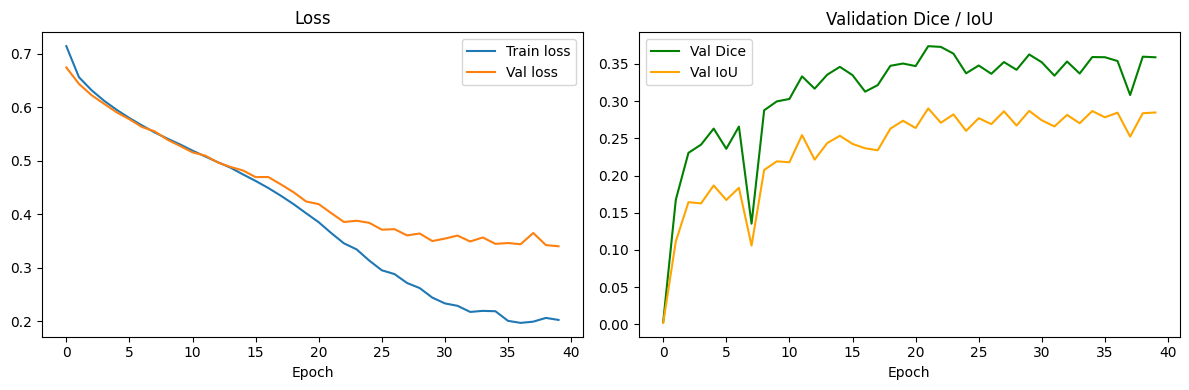

In [11]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"],   label="Val loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_dice"], label="Val Dice", color="green")
axes[1].plot(history["val_iou"],  label="Val IoU",  color="orange")
axes[1].set_title("Validation Dice / IoU"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUT / "attention_unet_curves.png", dpi=150)
plt.show()

In [12]:
# Load best weights, evaluate on test set 
model.load_state_dict(torch.load(S_WEIGHTS, map_location=DEVICE))
model.eval()

test_metrics = evaluate(model, test_dl)
print("── Test Set Results ──")
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

── Test Set Results ──
  dice_mean   : 0.3681
  dice_std    : 0.3719
  iou_mean    : 0.2979
  iou_std     : 0.3204


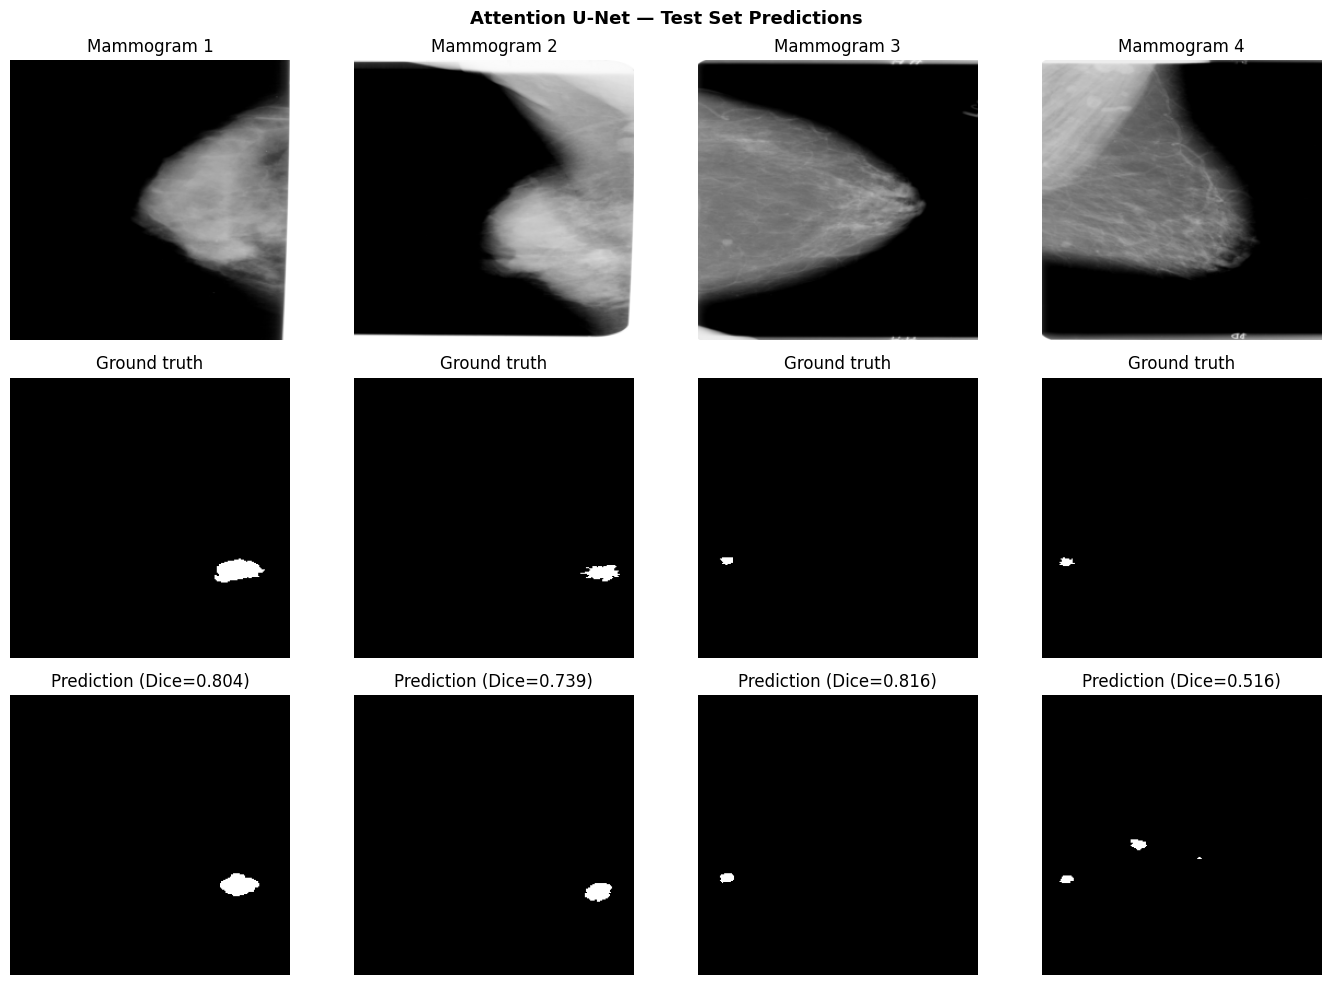

In [13]:
# Predictions vs ground truth
@torch.no_grad()
def get_sample_predictions(model, dataloader, n=4, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(dataloader))
    imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
    logits = model(imgs)
    preds = (torch.sigmoid(logits) >= threshold).float()
    return (imgs[:n].cpu(), masks[:n].cpu(), preds[:n].cpu())


sample_imgs, sample_masks, sample_preds = get_sample_predictions(model, test_dl, n=4)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i in range(4):
    axes[0, i].imshow(sample_imgs[i, 0], cmap="gray")
    axes[0, i].set_title(f"Mammogram {i+1}"); axes[0, i].axis("off")

    axes[1, i].imshow(sample_masks[i, 0], cmap="gray")
    axes[1, i].set_title("Ground truth"); axes[1, i].axis("off")

    axes[2, i].imshow(sample_preds[i, 0], cmap="gray")
    d = dice_coefficient(sample_preds[i], sample_masks[i]).item()
    axes[2, i].set_title(f"Prediction (Dice={d:.3f})"); axes[2, i].axis("off")

plt.suptitle("Attention U-Net Test Set Predictions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "attention_unet_predictions.png", dpi=150)
plt.show()

In [25]:
# Save results
results = {
    "model": "attention_unet_from_scratch",
    "img_size": IMG_SIZE,
    "base_channels": 32,
    "history": history,
    "val_metrics_best": {
        "dice_mean": history["val_dice"][-(PATIENCE if patience_counter >= PATIENCE else 1)],
    },
    "test_metrics": test_metrics,
    "hyperparameters": {
        "lr": LR,
        "epochs_run": len(history["train_loss"]),
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE,
        "bce_dice_weight": 0.5,
    },
    "n_train_cases": len(train_df),
    "n_val_cases": len(val_df),
    "n_test_cases": len(test_df),
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_JSON)

print("=" * 55)
print("  NB10: ATTENTION U-NET SEGMENTATION  FINAL RESULTS")
print("=" * 55)
print(f"  Test Dice : {test_metrics['dice_mean']:.4f} ± {test_metrics['dice_std']:.4f}")
print(f"  Test IoU  : {test_metrics['iou_mean']:.4f} ± {test_metrics['iou_std']:.4f}")
print("=" * 55)

Saved: /kaggle/working/attention_unet_results.json
  NB10: ATTENTION U-NET SEGMENTATION  FINAL RESULTS
  Test Dice : 0.3681 ± 0.3719
  Test IoU  : 0.2979 ± 0.3204


Error checking: why is the dice +- so near to value

Dice distribution:
  Median: 0.2872
  Cases with Dice < 0.05 (near-total failure): 170 / 378
  Cases with Dice > 0.50 (reasonable):          165 / 378

Predicted positive-pixel fraction mean: 0.00435, cases predicting ~0 positives: 88
True positive-pixel fraction  mean: 0.00495


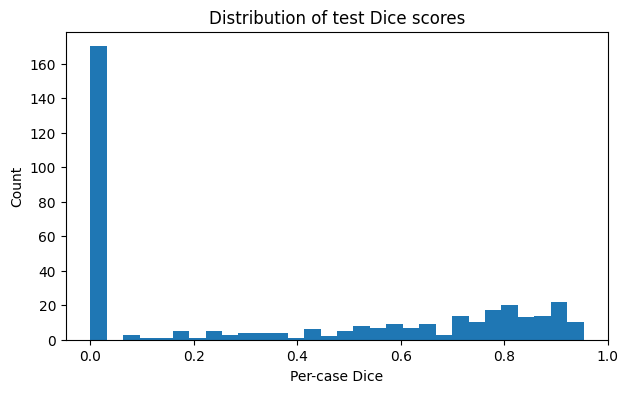

In [24]:
# Is Dice bimodal? Predictions collapsing to background?
@torch.no_grad()
def per_case_dice(model, dataloader, threshold=0.5):
    model.eval()
    scores = []
    pred_positive_fractions = []
    true_positive_fractions = []
    for imgs, masks in dataloader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) >= threshold).float()
        for i in range(preds.size(0)):
            d = dice_coefficient(preds[i], masks[i]).item()
            scores.append(d)
            pred_positive_fractions.append(preds[i].mean().item())
            true_positive_fractions.append(masks[i].mean().item())
    return np.array(scores), np.array(pred_positive_fractions), np.array(true_positive_fractions)

test_scores, pred_frac, true_frac = per_case_dice(model, test_dl)

print(f"Dice distribution:")
print(f"  Median: {np.median(test_scores):.4f}")
print(f"  Cases with Dice < 0.05 (near-total failure): {(test_scores < 0.05).sum()} / {len(test_scores)}")
print(f"  Cases with Dice > 0.50 (reasonable):          {(test_scores > 0.50).sum()} / {len(test_scores)}")

print(f"\nPredicted positive-pixel fraction mean: {pred_frac.mean():.5f}, cases predicting ~0 positives: {(pred_frac < 0.0001).sum()}")
print(f"True positive-pixel fraction  mean: {true_frac.mean():.5f}")

plt.figure(figsize=(7,4))
plt.hist(test_scores, bins=30)
plt.xlabel("Per-case Dice"); plt.ylabel("Count")
plt.title("Distribution of test Dice scores")
plt.show()

In [19]:
# Separate the failure modes: empty prediction vs wrong-location
near_zero_pred = pred_frac < 0.0001
low_dice       = test_scores < 0.05

empty_and_failed     = np.sum(near_zero_pred & low_dice)
nonempty_but_failed  = np.sum(~near_zero_pred & low_dice)

print(f"Failed AND predicted empty:      {empty_and_failed}")
print(f"Failed but predicted SOMETHING:  {nonempty_but_failed}  <- wrong location, not collapse")

# Check whether failures correlate with true lesion size —
# are small lesions disproportionately the failures?
fail_true_frac    = true_frac[low_dice]
success_true_frac = true_frac[test_scores > 0.5]

print(f"\nMean true lesion fraction failed cases:  {fail_true_frac.mean():.5f}")
print(f"Mean true lesion fraction successful cases: {success_true_frac.mean():.5f}")

Failed AND predicted empty:      88
Failed but predicted SOMETHING:  82  <- wrong location, not collapse

Mean true lesion fraction — failed cases:  0.00439
Mean true lesion fraction — successful cases: 0.00544


In [20]:
# Raw probability mass on true-lesion pixels vs elsewhere
@torch.no_grad()
def prob_on_lesion_vs_background(model, dataloader):
    model.eval()
    lesion_probs = []
    bg_probs = []
    for imgs, masks in dataloader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        probs = torch.sigmoid(model(imgs))
        for i in range(probs.size(0)):
            m = masks[i].bool()
            if m.sum() > 0:
                lesion_probs.append(probs[i][m].mean().item())
            bg_probs.append(probs[i][~m].mean().item())
    return np.array(lesion_probs), np.array(bg_probs)

lesion_p, bg_p = prob_on_lesion_vs_background(model, test_dl)
print(f"Mean predicted probability ON true lesion pixels: {lesion_p.mean():.4f}")
print(f"Mean predicted probability on background pixels:  {bg_p.mean():.4f}")
print(f"Fraction of lesion-mean-prob values above 0.5: {(lesion_p > 0.5).mean():.2%}")

Mean predicted probability ON true lesion pixels: 0.4264
Mean predicted probability on background pixels:  0.0024
Fraction of lesion-mean-prob values above 0.5: 46.30%


In [21]:
# Re-evaluate at a lower threshold (same weights, no retraining)
for thresh in [0.5, 0.4, 0.3, 0.25, 0.2]:
    metrics = evaluate(model, test_dl, threshold=thresh)
    print(f"threshold={thresh:.2f}  dice={metrics['dice_mean']:.4f}  iou={metrics['iou_mean']:.4f}")

threshold=0.50  dice=0.3681  iou=0.2979
threshold=0.40  dice=0.3681  iou=0.2975
threshold=0.30  dice=0.3683  iou=0.2972
threshold=0.25  dice=0.3684  iou=0.2970
threshold=0.20  dice=0.3681  iou=0.2964


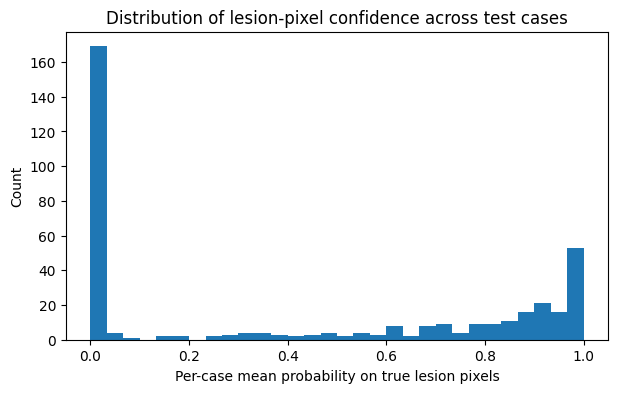

Cases with lesion-pixel mean prob < 0.05: 171 / 378
Cases with lesion-pixel mean prob > 0.5:  175 / 378


In [22]:
# Is lesion-pixel probability bimodal across cases
plt.figure(figsize=(7,4))
plt.hist(lesion_p, bins=30)
plt.xlabel("Per-case mean probability on true lesion pixels")
plt.ylabel("Count")
plt.title("Distribution of lesion-pixel confidence across test cases")
plt.show()

print(f"Cases with lesion-pixel mean prob < 0.05: {(lesion_p < 0.05).sum()} / {len(lesion_p)}")
print(f"Cases with lesion-pixel mean prob > 0.5:  {(lesion_p > 0.5).sum()} / {len(lesion_p)}")

In [23]:
# Do failing cases share other characteristics (pathology subtype, breast density, mass shape, etc.)
fail_mask = lesion_p < 0.05
success_mask = lesion_p > 0.5

fail_rows = test_df.iloc[np.where(fail_mask)[0]]
success_rows = test_df.iloc[np.where(success_mask)[0]]

print("=== mass shape ===")
print("Failing cases:")
print(fail_rows['mass shape'].value_counts(normalize=True).head(5))
print("\nSuccessful cases:")
print(success_rows['mass shape'].value_counts(normalize=True).head(5))

print("\n=== breast_density ===")
print("Failing:", fail_rows['breast_density'].value_counts(normalize=True).sort_index())
print("Successful:", success_rows['breast_density'].value_counts(normalize=True).sort_index())

print("\n=== pathology ===")
print("Failing:", fail_rows['pathology'].value_counts(normalize=True))
print("Successful:", success_rows['pathology'].value_counts(normalize=True))

=== mass shape ===
Failing cases:
mass shape
OVAL                        0.257310
LOBULATED                   0.222222
IRREGULAR                   0.204678
ROUND                       0.111111
ARCHITECTURAL_DISTORTION    0.099415
Name: proportion, dtype: float64

Successful cases:
mass shape
IRREGULAR                   0.348571
OVAL                        0.234286
LOBULATED                   0.211429
ROUND                       0.108571
ARCHITECTURAL_DISTORTION    0.034286
Name: proportion, dtype: float64

=== breast_density ===
Failing: breast_density
1    0.099415
2    0.391813
3    0.368421
4    0.140351
Name: proportion, dtype: float64
Successful: breast_density
1    0.177143
2    0.537143
3    0.205714
4    0.080000
Name: proportion, dtype: float64

=== pathology ===
Failing: pathology
BENIGN                     0.602339
MALIGNANT                  0.239766
BENIGN_WITHOUT_CALLBACK    0.157895
Name: proportion, dtype: float64
Successful: pathology
MALIGNANT                  0.514286